# IdiomX – Task 2: Context-to-Idiom Retrieval (Main Benchmark)

This notebook presents the main **Task 2** benchmark for **IdiomX** using the **high-quality dataset split**.

## Task definition

Given an **English idiomatic contextual sentence**, the goal is to retrieve the correct **canonical idiom** from a fixed idiom inventory.

This is a **closed-set retrieval task**:
- input: idiomatic contextual sentence
- output: canonical idiom
- prediction space: fixed idiom bank

## Experimental design

This notebook is intentionally kept clean and publication-ready.

It uses:
- one **final query-level leakage-safe split strategy**
- one **strong baseline**
- one **best final model**

The two evaluated systems are:
1. **MiniLM dense retrieval**
2. **Hybrid retrieval with cross-encoder reranking**

## Evaluation metrics

We report:
- **Top-1 Accuracy**
- **Top-3 Accuracy**
- **Top-5 Accuracy**
- **Mean Reciprocal Rank (MRR)**

The notebook is designed for:
- reproducibility
- clean research reporting
- GitHub publication
- direct integration into the research paper

In [1]:
# [1.1] Environment setup and reproducibility

from pathlib import Path
import warnings
import random
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

print("Environment setup complete.")
print(f"Random seed: {SEED}")

Environment setup complete.
Random seed: 42


In [2]:
# [2.1] Load IdiomX high-quality dataset (minimal output)

from datasets import load_dataset

HF_DATASET_ID = "aymansharara/IdiomX"
CONFIG_NAME = "idiomx_high_quality"

dataset = load_dataset(HF_DATASET_ID, CONFIG_NAME)

print("Dataset loaded successfully.")
print("Available splits:", list(dataset.keys()))

Dataset loaded successfully.
Available splits: ['idiomx_high_quality_train', 'idiomx_high_quality_test']


In [3]:
# [2.2] Inspect dataset structure (light preview)

df = dataset[list(dataset.keys())[0]].to_pandas()

print("Shape:", df.shape)
print("Columns:", list(df.columns))

df.head(2)

Shape: (98413, 52)
Columns: ['idiom_id', 'idiom_canonical', 'example', 'example_usage_label', 'idiom_canonical_meaning', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'example_raw', 'example_language', 'source', 'source_type', 'source_url', 'record_origin', 'license_source', 'idiom_surface', 'pos', 'tags', 'idiom_confidence', 'is_example_idiom', 'is_generated_example', 'is_adversarial_example', 'meaning_language', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_in_example_arabic', 'enrichment_model', 'enrichment_version', 'validation_status', 'context_type', 'source_style', 'hard_negative_idioms', 'meaning_paraphrases_en', 'meaning_paraphrases_ar', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'explanation_en', 'explanation_ar', 'minimal_pair_id', 'paraphrase_group_id', 'adversarial_type', 'expected_label', 'row_type', 'example_normalized', 's

,idiom_id,idiom_canonical,example,example_usage_label,idiom_canonical_meaning,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,example_raw,example_language,source,source_type,source_url,record_origin,license_source,idiom_surface,pos,tags,idiom_confidence,is_example_idiom,is_generated_example,is_adversarial_example,meaning_language,idiom_canonical_meaning_arabic,is_idiom,ambiguity_flag,idiom_compositionality_level,idiom_register,idiom_domain,learner_difficulty,idiom_in_example_arabic,enrichment_model,enrichment_version,validation_status,context_type,source_style,hard_negative_idioms,meaning_paraphrases_en,meaning_paraphrases_ar,idiom_level_explanation_en,idiom_level_explanation_ar,explanation_en,explanation_ar,minimal_pair_id,paraphrase_group_id,adversarial_type,expected_label,row_type,example_normalized,sentence_length_chars,sentence_length_words,semantic_similarity_example_vs_meaning,semantic_quality
0,idiomx_543ff4605a0e,'ark at 'ee,Please ’ark at ’ee the microchip here to observe the auditory sensor’s location.,literal,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Literal direction to look at the specific part corresponding to an ear on a device.,توجيه حرفي للنظر إلى جزء معين يشبه الأذن في جهاز.,"‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget pointed ahead. ‘Yurr oi think et wursens yonder, ’ark at ee roaren et makes!’",en,kaikki_wiktionary,dictionary,NaN,llm_enriched_v2,wiktionary_cc_by_sa_4_0,'ark at 'ee,phrase,informal,high,False,1,0,en,"تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أو للتعبير عن الدهشة من كلامه، بمعنى ""استمع إلى ما تقول!"" أو ""انظر إلى ذلك!""",True,strongly_idiomatic,opaque,informal,regional,hard,يرجى النظر إلى الأذن في هذه الشريحة الإلكترونية لمراقبة موقع حساس السمع.,gpt-4.1-mini-2025-04-14,v2,valid,formal,synthetic_narrative,"[""listen up"", ""hear me out"", ""look who's talking""]","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]","[""انتبه إلى ما يقال"", ""استمع إلى ذلك القول المفاجئ"", ""اعتبر كلمات المتحدث""]",This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...,"هذه العبارة تعبير مجازي لأنها تستخدم اختصارًا لهجة وعبارة تعجبية لا تعني حرفيًا ""انظر إلى الأذن"" بل تأمر بالانتباه إلى كلام أو رأي شخص ما.",Literal technical instruction without figurative meaning.,تعليمات حرفية تقنية بدون معنى مجازي.,pair_0bd2fe08fbde,paraphrase_6a8ebd5786f7,None,literal,main_example,please ark at ee the microchip here to observe the auditory sensors location,80,13,0.522272,high
1,idiomx_543ff4605a0e,'ark at 'ee,Can you ’ark at ’ee how clear the sound is from my new headphones? #literal,literal,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Literal use describing sound clarity near the ear.,استخدام حرفي يصف وضوح الصوت بالقرب من الأذن.,"‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget pointed ahead. ‘Yurr oi think et wursens yonder, ’ark at ee roaren et makes!’",en,kaikki_wiktionary,dictionary,NaN,llm_enriched_v2,wiktionary_cc_by_sa_4_0,'ark at 'ee,phrase,informal,high,False,1,0,en,"تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أو للتعبير عن الدهشة من كلامه، بمعنى ""استمع إلى ما تقول!"" أو ""انظر إلى ذلك!""",True,strongly_idiomatic,opaque,informal,regional,hard,هل يمكنك النظر إلى الأذن كيف واضح الصوت من سماعاتي الجديدة؟ #حرفي,gpt-4.1-mini-2025-04-14,v2,valid,social_media,synthetic_narrative,"[""listen up"", ""hear me out"", ""look who's talking""]","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Co

In [4]:
# [2.3] Build Task 2 working dataframe (query + semantic fields)

task2_df = df[
    [
        # --- Core identifiers ---
        "idiom_id",
        "idiom_canonical",

        # --- Query side ---
        "example",

        # --- Labels / filtering ---
        "example_usage_label",
        "is_example_idiom",
        "validation_status",
        "semantic_quality",

        # --- Semantic fields (for bank construction later) ---
        "idiom_canonical_meaning",
        "meaning_paraphrases_en",
        "idiom_level_explanation_en"
    ]
].copy()

print("Task 2 base dataframe created.")
print("Shape:", task2_df.shape)

Task 2 base dataframe created.
Shape: (98413, 10)


In [5]:
# [2.4] Quick preview

task2_df.head(3)

,idiom_id,idiom_canonical,example,example_usage_label,is_example_idiom,validation_status,semantic_quality,idiom_canonical_meaning,meaning_paraphrases_en,idiom_level_explanation_en
0,idiomx_543ff4605a0e,'ark at 'ee,Please ’ark at ’ee the microchip here to observe the auditory sensor’s location.,literal,False,valid,high,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]",This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...
1,idiomx_543ff4605a0e,'ark at 'ee,Can you ’ark at ’ee how clear the sound is from my new headphones? #literal,literal,False,valid,high,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]",This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...
2,idiomx_543ff4605a0e,'ark at 'ee,Can you ’ark at ’ee the diagram to find the auditory nerve?,literal,False,valid,high,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]",This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...


In [6]:
# [2.5] Validate is_example_idiom field

print("Null count:", task2_df["is_example_idiom"].isna().sum())

print("\nValue distribution:")
print(task2_df["is_example_idiom"].value_counts(dropna=False, normalize=True))

Null count: 4902

Value distribution:
is_example_idiom
False    0.538404
True     0.411785
None     0.049810
Name: proportion, dtype: float64


In [7]:
# [2.6] Consistency check: label vs is_example_idiom

pd.crosstab(
    task2_df["example_usage_label"],
    task2_df["is_example_idiom"],
    normalize="index"
)

is_example_idiom,False,True
example_usage_label,,
borderline,0.000000,1.000000
idiomatic,0.000025,0.999975
literal,0.999849,0.000151


We restrict training and evaluation to idiomatic usage examples to ensure that each query sentence semantically expresses the idiom meaning, avoiding noise from literal interpretations.

In [8]:
# [3.1] Filter to clean idiomatic Task 2 dataset

filtered_df = task2_df[
    (task2_df["is_example_idiom"] == True) &
    (task2_df["validation_status"] == "valid") &
    (task2_df["semantic_quality"] == "high")
].copy()

print("Filtered dataset shape:", filtered_df.shape)

print("\nLabel distribution:")
print(filtered_df["example_usage_label"].value_counts(normalize=True))

Filtered dataset shape: (38604, 10)

Label distribution:
example_usage_label
idiomatic    1.0
Name: proportion, dtype: float64


In [9]:
# [3.2] Sanity checks

print("Unique idioms:", filtered_df["idiom_canonical"].nunique())
print("Examples:", len(filtered_df))

filtered_df.head(3)

Unique idioms: 11626
Examples: 38604


,idiom_id,idiom_canonical,example,example_usage_label,is_example_idiom,validation_status,semantic_quality,idiom_canonical_meaning,meaning_paraphrases_en,idiom_level_explanation_en
3,idiomx_7fd1dd45c159,'fraid so,"'Fraid so, the meeting's been canceled.",idiomatic,True,valid,high,"An informal way to confirm that something is true, especially when the news might be unwelcome or disappointing.","[""Yes, unfortunately that is correct."", ""I regret to say that is true."", ""That is indeed the case, sadly.""]","The phrase ""'fraid so"" is a contracted, informal form meaning ""I am afraid so,"" used idiomatically to acknowledge the truth of a statement, usually with some regret or reluctance, rather than fear."
4,idiomx_7fd1dd45c159,'fraid so,"When asked if the project was delayed, he said, ''fraid so.'",idiomatic,True,valid,high,"An informal way to confirm that something is true, especially when the news might be unwelcome or disappointing.","[""Yes, unfortunately that is correct."", ""I regret to say that is true."", ""That is indeed the case, sadly.""]","The phrase ""'fraid so"" is a contracted, informal form meaning ""I am afraid so,"" used idiomatically to acknowledge the truth of a statement, usually with some regret or reluctance, rather than fear."
8,idiomx_dd41993ed905,110 proof,This new coffee blend is 110 proof in caffeine kick.,idiomatic,True,valid,high,"Extremely strong or potent, usually referring to alcohol or metaphorically to intensity or effectiveness.","[""exceptionally strong or intense"", ""more potent than usual"", ""powerful beyond the norm""]",The phrase '110 proof' originates from alcohol grading systems indicating strength above the standard 100 proof. It's used idiomatically to describe something extremely strong or potent beyond the...


In [10]:
# [4.1] Shuffle dataset (important before splitting)

SEED = 42  # fixed seed for reproducibility

filtered_df = filtered_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Shuffled dataset.")
print("Shape:", filtered_df.shape)

Shuffled dataset.
Shape: (38604, 10)


### Split Strategy

We use a query-level split:
- sentences are split randomly
- idioms may appear in both splits
- no sentence leakage between train and test

This reflects a realistic closed-set retrieval setup.

# [4.2] Train / Test split (query-level)

split_ratio = 0.8
split_idx = int(len(filtered_df) * split_ratio)

train_df = filtered_df.iloc[:split_idx].copy()
test_df  = filtered_df.iloc[split_idx:].copy()

print("Train size:", len(train_df))
print("Test size :", len(test_df))

In [11]:
# [4.2] Train / Test split by idiom (NO leakage)

import numpy as np

SEED = 42
split_ratio = 0.8

# Get unique idioms
unique_idioms = filtered_df["idiom_canonical"].unique()

# Shuffle idioms
np.random.seed(SEED)
np.random.shuffle(unique_idioms)

# Split idioms
split_idx = int(len(unique_idioms) * split_ratio)

train_idioms = set(unique_idioms[:split_idx])
test_idioms  = set(unique_idioms[split_idx:])

# Build datasets
train_df = filtered_df[filtered_df["idiom_canonical"].isin(train_idioms)].copy()
test_df  = filtered_df[filtered_df["idiom_canonical"].isin(test_idioms)].copy()

print("Train idioms:", len(train_idioms))
print("Test idioms :", len(test_idioms))
print("Train size  :", len(train_df))
print("Test size   :", len(test_df))

Train idioms: 9300
Test idioms : 2326
Train size  : 31002
Test size   : 7602


In [12]:
# [4.3] Split sanity checks

print("Train unique idioms:", train_df["idiom_canonical"].nunique())
print("Test unique idioms :", test_df["idiom_canonical"].nunique())

overlap = set(train_df["idiom_canonical"]).intersection(set(test_df["idiom_canonical"]))

print("Shared idioms between splits:", len(overlap))

Train unique idioms: 9300
Test unique idioms : 2326
Shared idioms between splits: 0


## Idiom Bank

We construct a semantic idiom-level bank by grouping all examples
at the idiom level and aggregating meaning-related fields.

Unlike earlier versions where only `idiom_canonical` was used,
this bank includes richer semantic information such as:

- idiom meaning
- paraphrases
- explanations

This ensures that retrieval is based on semantic similarity,
not just surface form matching.

In [13]:
# [5.1] Build semantic idiom-level bank (correct location)

def first_nonempty(series):
    """Return the first non-empty string in a series."""
    for x in series:
        if pd.notna(x) and str(x).strip():
            return str(x).strip()
    return ""

# Build idiom-level bank from FULL dataset (NOT filtered_df)
task2_bank_df = (
    df.groupby("idiom_canonical", as_index=False)
    .agg({
        "idiom_canonical_meaning": first_nonempty,
        "meaning_paraphrases_en": first_nonempty,
        "idiom_level_explanation_en": first_nonempty
    })
    .copy()
)

print("Task 2 idiom-level bank created.")
print("Shape:", task2_bank_df.shape)

task2_bank_df.head(3)

Task 2 idiom-level bank created.
Shape: (12522, 4)


,idiom_canonical,idiom_canonical_meaning,meaning_paraphrases_en,idiom_level_explanation_en
0,'ark at 'ee,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]",This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...
1,'fraid so,"An informal way to confirm that something is true, especially when the news might be unwelcome or disappointing.","[""Yes, unfortunately that is correct."", ""I regret to say that is true."", ""That is indeed the case, sadly.""]","The phrase ""'fraid so"" is a contracted, informal form meaning ""I am afraid so,"" used idiomatically to acknowledge the truth of a statement, usually with some regret or reluctance, rather than fear."
2,(my|your|his|her|their) two cents,"A humble or unsolicited opinion or piece of advice, usually presented as modest or insignificant but offered nonetheless.","[""a modest opinion"", ""an unsolicited suggestion"", ""a humble contribution to a discussion""]","The phrase 'two cents' is idiomatic because it metaphorically represents contributing a small, often humble opinion rather than a literal monetary value. It is used figuratively in conversation to..."


### Build semantic bank text

We combine idiom-level semantic fields into a single bank text per idiom.

This text will be embedded and used for dense retrieval, so it should
capture the idiom surface form together with its meaning and explanation.

In [14]:
# [5.2] Build semantic bank text

task2_bank_df["bank_text"] = (
    "idiom: " + task2_bank_df["idiom_canonical"].fillna("").astype(str).str.strip() +
    ". meaning: " + task2_bank_df["idiom_canonical_meaning"].fillna("").astype(str).str.strip() +
    ". paraphrase: " + task2_bank_df["meaning_paraphrases_en"].fillna("").astype(str).str.strip() +
    ". explanation: " + task2_bank_df["idiom_level_explanation_en"].fillna("").astype(str).str.strip()
)

# Clean repeated spaces
task2_bank_df["bank_text"] = (
    task2_bank_df["bank_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Bank text created.")
task2_bank_df[
    [
        "idiom_canonical",
        "idiom_canonical_meaning",
        "meaning_paraphrases_en",
        "idiom_level_explanation_en",
        "bank_text"
    ]
].head(3)

Bank text created.


,idiom_canonical,idiom_canonical_meaning,meaning_paraphrases_en,idiom_level_explanation_en,bank_text
0,'ark at 'ee,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]",This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...,"idiom: 'ark at 'ee. meaning: An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'. par..."
1,'fraid so,"An informal way to confirm that something is true, especially when the news might be unwelcome or disappointing.","[""Yes, unfortunately that is correct."", ""I regret to say that is true."", ""That is indeed the case, sadly.""]","The phrase ""'fraid so"" is a contracted, informal form meaning ""I am afraid so,"" used idiomatically to acknowledge the truth of a statement, usually with some regret or reluctance, rather than fear.","idiom: 'fraid so. meaning: An informal way to confirm that something is true, especially when the news might be unwelcome or disappointing.. paraphrase: [""Yes, unfortunately that is correct."", ""I ..."
2,(my|your|his|her|their) two cents,"A humble or unsolicited opinion or piece of advice, usually presented as modest or insignificant but offered nonetheless.","[""a modest opinion"", ""an unsolicited suggestion"", ""a humble contribution to a discussion""]","The phrase 'two cents' is idiomatic because it metaphorically represents contributing a small, often humble opinion rather than a literal monetary value. It is used figuratively in conversation to...","idiom: (my|your|his|her|their) two cents. meaning: A humble or unsolicited opinion or piece of advice, usually presented as modest or insignificant but offered nonetheless.. paraphrase: [""a modest..."


### Creating Idiom Index Mapping

We assign each idiom a unique numeric index.

This makes evaluation easier because the retrieval target can be represented as a single label instead of raw text.

In [15]:
# [5.3] Create idiom ↔ index mapping (from semantic bank)

idiom_list = task2_bank_df["idiom_canonical"].tolist()

idiom_to_idx = {idiom: i for i, idiom in enumerate(idiom_list)}
idx_to_idiom = {i: idiom for idiom, i in idiom_to_idx.items()}

print("Mapping created.")
print("Total idioms:", len(idiom_to_idx))

Mapping created.
Total idioms: 12522


### Assigning Target Labels

We map the gold idiom of each train and test example to its numeric index.

These target indices will be used later to evaluate whether retrieval returns the correct idiom.

In [16]:
# [5.4] Convert targets to indices

train_df["target"] = train_df["idiom_canonical"].map(idiom_to_idx)
test_df["target"]  = test_df["idiom_canonical"].map(idiom_to_idx)

print("Targets assigned.")
print("Train null targets:", train_df["target"].isna().sum())
print("Test null targets :", test_df["target"].isna().sum())

Targets assigned.
Train null targets: 0
Test null targets : 0


### Loading the Dense Retrieval Model

We load MiniLM as the main dense retrieval baseline.

This model converts both sentences and idioms into embeddings that can be compared in the same semantic space.

In [17]:
# [6.1] Load MiniLM sentence embedding model

from sentence_transformers import SentenceTransformer

model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name)

print("MiniLM model loaded.")

MiniLM model loaded.


### Encoding Idiom Bank

We encode the **semantic idiom bank** into dense vector representations using MiniLM.

Instead of encoding only the idiom surface form, we encode the richer
`bank_text` field, which combines the idiom, its meaning, paraphrases,
and explanation.

These embeddings form the retrieval index used to compare each query
sentence against all candidate idioms.

In [18]:
# [6.2] Encode semantic idiom bank

# Use the semantic bank text, not only the idiom surface form
bank_texts = task2_bank_df["bank_text"].tolist()

# Encode all idioms into dense vectors
idiom_embeddings = embedder.encode(
    bank_texts,
    batch_size=64,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Idiom embeddings shape:", idiom_embeddings.shape)

Batches:   0%|          | 0/196 [00:00<?, ?it/s]

Idiom embeddings shape: (12522, 384)


### Encoding Query Sentences

We encode each test sentence into a vector representation.

These query embeddings will be compared against the idiom bank to retrieve the most similar idioms.

In [19]:
# [6.3] Encode test queries
import numpy as np

# Use the query sentences from the test split
test_texts = test_df["example"].tolist()

# Encode test queries into dense vectors
test_embeddings = embedder.encode(
    test_texts,
    batch_size=64,          # larger batch for faster encoding
    convert_to_numpy=True,
    show_progress_bar=True
)

# Normalize query embeddings so dot product = cosine similarity
test_embeddings = test_embeddings / np.linalg.norm(
    test_embeddings, axis=1, keepdims=True
)

print("Test embeddings shape:", test_embeddings.shape)

Batches:   0%|          | 0/119 [00:00<?, ?it/s]

Test embeddings shape: (7602, 384)


In [20]:
# [6.4] Normalize idiom bank embeddings

import numpy as np

# Normalize bank embeddings so dot product = cosine similarity
idiom_embeddings = idiom_embeddings / np.linalg.norm(
    idiom_embeddings, axis=1, keepdims=True
)

print("Idiom bank embeddings normalized.")

Idiom bank embeddings normalized.


### Computing Dense Similarity

We compare each query embedding with all idiom embeddings.

This produces a similarity score for every query–idiom pair, which is then used for ranking.

In [21]:
# [6.5] Compute similarity matrix (cosine similarity via dot product)

similarity_matrix = np.dot(test_embeddings, idiom_embeddings.T)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (7602, 12522)


### Evaluating Dense Retrieval

We rank idioms by similarity and measure whether the correct idiom appears among the top predictions.

This gives the main retrieval metrics: Top-1, Top-3, Top-5, and MRR.

In [22]:
# [6.6] Evaluate retrieval (Top-k + MRR)

targets = test_df["target"].values

top_k = [1, 3, 5]
correct_at_k = {k: 0 for k in top_k}
mrr_total = 0

for i in range(len(similarity_matrix)):
    scores = similarity_matrix[i]

    # Sort indices in descending order (highest similarity first)
    ranked_indices = np.argsort(-scores)

    target = targets[i]

    # --- Top-k accuracy ---
    for k in top_k:
        top_k_indices = ranked_indices[:k]

        # Check if target is inside top-k predictions
        if target in top_k_indices:
            correct_at_k[k] += 1

    # --- MRR ---
    # Find position of correct target in ranked list
    rank = np.where(ranked_indices == target)[0][0] + 1
    mrr_total += 1.0 / rank


# --- Final metrics ---
results = {
    f"Top-{k} Accuracy": correct_at_k[k] / len(similarity_matrix)
    for k in top_k
}

results["MRR"] = mrr_total / len(similarity_matrix)

print("\nEvaluation Results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


Evaluation Results:
Top-1 Accuracy: 0.6026
Top-3 Accuracy: 0.7149
Top-5 Accuracy: 0.7518
MRR: 0.6725


### Dense retrieval debug examples

We inspect a few test queries together with their top retrieved idioms
to verify that the semantic idiom bank is returning meaningful candidates.

In [23]:
# [6.7] Debug dense retrieval examples

def show_dense_predictions(example_idx, top_n=5):
    query = test_df.iloc[example_idx]["example"]
    true_idiom = test_df.iloc[example_idx]["idiom_canonical"]
    target_idx = test_df.iloc[example_idx]["target"]

    scores = similarity_matrix[example_idx]
    ranked_indices = np.argsort(-scores)[:top_n]

    print("=" * 100)
    print(f"Query      : {query}")
    print(f"True idiom : {true_idiom}")
    print(f"Target idx : {target_idx}")
    print("-" * 100)

    for rank, idx in enumerate(ranked_indices, start=1):
        pred_idiom = idx_to_idiom[idx]
        score = scores[idx]
        marker = "✅" if pred_idiom == true_idiom else ""
        print(f"{rank:>2}. {pred_idiom:<35} score={score:.4f} {marker}")

# Try a few examples
for i in [0, 1, 2, 10, 25]:
    show_dense_predictions(i, top_n=5)
    print()

Query      : Attendees received the inside scoop on upcoming regulatory changes during the briefing.
True idiom : inside scoop
Target idx : 5804
----------------------------------------------------------------------------------------------------
 1. inside scoop                        score=0.5094 ✅
 2. get the memo                        score=0.3792 
 3. in other news                       score=0.3580 
 4. in the hopper                       score=0.3411 
 5. film at 11                          score=0.3387 

Query      : I think you overstepped the mark by criticizing her work so harshly.
True idiom : overstep the mark
Target idx : 8008
----------------------------------------------------------------------------------------------------
 1. cast aspersions                     score=0.3548 
 2. who's 'she', the cat's mother       score=0.3208 
 3. overstep the mark                   score=0.3187 ✅
 4. The lady doth protest too much, methinks score=0.3042 
 5. Disgusted of Tunbridge W

### Random dense retrieval inspection

We inspect a few random test examples to get a less biased view of
dense retrieval behavior after rebuilding the semantic idiom bank.

In [24]:
# [6.8] Random dense retrieval inspection

rng = np.random.default_rng(42)
random_indices = rng.choice(len(test_df), size=5, replace=False)

for i in random_indices:
    show_dense_predictions(i, top_n=5)
    print()

Query      : That new manager is hell on wheels, but somehow gets results! #bosslife
True idiom : hell on wheels
Target idx : 5125
----------------------------------------------------------------------------------------------------
 1. on wheels                           score=0.3518 
 2. hell on wheels                      score=0.3496 ✅
 3. a new broom sweeps clean            score=0.3380 
 4. at the wheel                        score=0.3375 
 5. final boss                          score=0.3354 

Query      : Our marriage has honestly turned into a dead bedroom lately, and it's causing tension.
True idiom : dead bedroom
Target idx : 2986
----------------------------------------------------------------------------------------------------
 1. dead bedroom                        score=0.6232 ✅
 2. marriage bed                        score=0.4511 
 3. sleep together                      score=0.4085 
 4. the family that sleeps together keeps together score=0.3943 
 5. shacked up         

---

### Preparing the Lexical Retrieval Component

We add BM25 as a lexical retrieval model.

Unlike MiniLM, BM25 focuses on token overlap, which can help when the query shares important words with the target idiom.

### Hybrid Retrieval Setup

We combine:
- dense similarity (MiniLM)
- lexical similarity (BM25)

This helps capture both semantic meaning and exact phrase overlap, improving retrieval performance.

In [25]:
# [7.1] Ensure BM25 is available (reproducible setup)

# This cell ensures the BM25 library is installed.
# It allows the notebook to run on any machine (Kaggle, local, HF Spaces).

import sys
import subprocess

try:
    from rank_bm25 import BM25Okapi
    print("BM25 already installed.")
except ImportError:
    print("Installing rank_bm25...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rank_bm25"])
    from rank_bm25 import BM25Okapi
    print("BM25 installed successfully.")

Installing rank_bm25...
BM25 installed successfully.


### "Build BM25 index over semantic idiom bank (bank_text)

We build a lexical retrieval index over the idiom bank.

BM25 complements dense retrieval by rewarding exact token overlap between the query and candidate idioms.

In [26]:
# [7.2] Build BM25 index over semantic idiom bank

# Use semantic text (NOT only idiom surface form)
bank_texts = task2_bank_df["bank_text"].tolist()

# Tokenize text for BM25 (simple whitespace tokenization)
# Note: BM25 is lexical → token overlap matters
idiom_tokens = [text.lower().split() for text in bank_texts]

# Build BM25 index
bm25 = BM25Okapi(idiom_tokens)

print("BM25 index ready.")
print("Indexed idioms:", len(idiom_tokens))

BM25 index ready.
Indexed idioms: 12522


### Computing Hybrid Scores

We combine dense semantic similarity (MiniLM) and lexical overlap (BM25) for each query.

This allows the model to use both semantic similarity and lexical overlap when ranking idioms.

In [30]:
# [7.3] Compute hybrid similarity scores

# Ensure tqdm is available (for progress bar)
try:
    from tqdm import tqdm
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tqdm"])
    from tqdm import tqdm

# Min-max normalization to [0, 1]
def minmax_normalize(scores):
    scores = np.asarray(scores, dtype=float)
    score_min = scores.min()
    score_max = scores.max()

    # Avoid division by zero for flat score vectors
    if score_max - score_min < 1e-12:
        return np.zeros_like(scores, dtype=float)

    return (scores - score_min) / (score_max - score_min)

# Dense similarity scores from MiniLM
dense_test_similarity = similarity_matrix.copy()

# Prepare hybrid similarity matrix
hybrid_test_similarity = np.zeros_like(dense_test_similarity, dtype=float)

# Combine dense + BM25 for each test query
for i, query_text in enumerate(tqdm(test_texts, desc="Computing hybrid scores")):
    # Dense semantic similarity
    dense_scores = dense_test_similarity[i]

    # BM25 lexical similarity
    query_tokens = query_text.lower().split()
    bm25_scores = np.asarray(bm25.get_scores(query_tokens), dtype=float)

    # Normalize both score types independently
    dense_scores_norm = minmax_normalize(dense_scores)
    bm25_scores_norm = minmax_normalize(bm25_scores)

    # Equal-weight hybrid combination
    hybrid_test_similarity[i] = (
    0.8 * dense_scores_norm +
    0.2 * bm25_scores_norm
    )

print("Hybrid similarity matrix shape:", hybrid_test_similarity.shape)

Computing hybrid scores: 100%|█████████████████████████████████████████████████████| 7602/7602 [11:34<00:00, 10.95it/s]

Hybrid similarity matrix shape: (7602, 12522)


### Evaluating Hybrid Retrieval

We evaluate the hybrid model using the same metrics as MiniLM.

This allows direct comparison to measure the impact of combining dense and lexical signals.

In [31]:
# [7.4] Evaluate hybrid retrieval

targets = test_df["target"].values

top_k = [1, 3, 5]
correct_at_k = {k: 0 for k in top_k}
mrr_total = 0

for i in range(len(hybrid_test_similarity)):
    scores = hybrid_test_similarity[i]

    # Sort in descending order
    ranked_indices = np.argsort(-scores)

    target = targets[i]

    # --- Top-k accuracy ---
    for k in top_k:
        top_k_indices = ranked_indices[:k]
        if target in top_k_indices:
            correct_at_k[k] += 1

    # --- MRR ---
    rank = np.where(ranked_indices == target)[0][0] + 1
    mrr_total += 1.0 / rank


# --- Final metrics ---
hybrid_results = {
    f"Top-{k} Accuracy": correct_at_k[k] / len(hybrid_test_similarity)
    for k in top_k
}

hybrid_results["MRR"] = mrr_total / len(hybrid_test_similarity)

print("\nHybrid Evaluation Results:")
for k, v in hybrid_results.items():
    print(f"{k}: {v:.4f}")


Hybrid Evaluation Results:
Top-1 Accuracy: 0.6423
Top-3 Accuracy: 0.7652
Top-5 Accuracy: 0.7994
MRR: 0.7156


### Hybrid Retrieval Results

Hybrid retrieval (MiniLM + BM25) provides a modest improvement over dense retrieval.

However, compared to earlier experiments using surface-form idiom banks, the improvement is significantly smaller.

This indicates that:
- Dense semantic embeddings already capture most of the useful signal
- Lexical matching (BM25) contributes only limited additional benefit
- Previous gains from hybrid retrieval were partially due to lexical bias

Overall, dense retrieval with a semantically enriched idiom bank remains the strongest and most stable approach.

### Baseline Comparison (Dense vs Hybrid)

We compare the MiniLM baseline and the Hybrid model across all evaluation metrics.

In [32]:
# [7.5] Create comparison table

minilm_results = results  # from earlier

comparison_df = pd.DataFrame([
    {"Model": "MiniLM", **minilm_results},
    {"Model": "Hybrid", **hybrid_results}
])

comparison_df

,Model,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,MRR
0,MiniLM,0.602605,0.714943,0.751776,0.672521
1,Hybrid,0.642331,0.765193,0.799395,0.715559


### Dense vs Hybrid Comparison

| Method | Top-1 | Top-3 | Top-5 | MRR |
|--------|------|------|------|------|
| Dense (MiniLM) | 0.6026 | 0.7149 | 0.7518 | 0.6725 |
| Hybrid (MiniLM + BM25) | 0.6423 | 0.7652 | 0.7994 | 0.7156 |

The results demonstrate that while hybrid retrieval can provide incremental gains, dense semantic retrieval using enriched idiom representations captures the majority of the signal, reducing the relative contribution of lexical matching.

### Hybrid + Reranker

We refine the hybrid retrieval results using a cross-encoder reranker.

Instead of scoring all idioms, we rerank only the top candidates from the hybrid model, improving precision while keeping computation efficient.

In [51]:
# [8.1] Load cross-encoder reranker

import os
from tqdm import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")

try:
    from sentence_transformers import CrossEncoder
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])
    from sentence_transformers import CrossEncoder

reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("Reranker model loaded.")

Reranker model loaded.


### Selecting Top Candidates for Reranking

We first keep only the top candidates returned by the hybrid model.

The reranker then focuses on this smaller candidate set, which makes the final step both faster and more precise.

In [52]:
# [8.2] Extract top-k hybrid candidates for reranking

rerank_top_k = 10

# Get top-k indices per query from hybrid similarity
# argsort returns full ranking → we slice only top-k
hybrid_topk_indices = np.argsort(-hybrid_test_similarity, axis=1)[:, :rerank_top_k]

print("Top-k candidate matrix shape:", hybrid_topk_indices.shape)
print("Candidates per query:", rerank_top_k)

Top-k candidate matrix shape: (7602, 10)
Candidates per query: 10


### Building Query–Candidate Pairs

For each test sentence, we pair the query with its top hybrid candidates.

These pairs are passed to the cross-encoder, which scores each candidate using direct query–idiom interaction.

In [66]:
# [8.3] Build query–candidate pairs for reranking

rerank_pairs = []

# Keep how many candidates were added for each query
# This is useful later when reshaping reranker scores back per query
rerank_pair_counts = []

# Loop over each test query
for query_idx, query_text in enumerate(test_texts):

    # Top-k candidate indices returned by hybrid retrieval
    candidate_indices = hybrid_topk_indices[query_idx]

    # Build [query, candidate_idiom] pairs directly
    for candidate_idx in candidate_indices:
        # Use only the idiom surface form for reranking
        candidate_idiom = idx_to_idiom[candidate_idx]
        rerank_pairs.append([query_text, candidate_idiom])
        
    # Should always be equal to rerank_top_k
    rerank_pair_counts.append(len(candidate_indices))

print("Total rerank pairs:", len(rerank_pairs))
print("Pairs per query   :", rerank_top_k)
print("Expected total    :", len(test_texts) * rerank_top_k)
print("Counts OK         :", all(c == rerank_top_k for c in rerank_pair_counts))

# Quick preview
rerank_pairs[:5]

Total rerank pairs: 76020
Pairs per query   : 10
Expected total    : 76020
Counts OK         : True


[['Attendees received the inside scoop on upcoming regulatory changes during the briefing.',
  'inside scoop'],
 ['Attendees received the inside scoop on upcoming regulatory changes during the briefing.',
  'this just in'],
 ['Attendees received the inside scoop on upcoming regulatory changes during the briefing.',
  'get the memo'],
 ['Attendees received the inside scoop on upcoming regulatory changes during the briefing.',
  'in other news'],
 ['Attendees received the inside scoop on upcoming regulatory changes during the briefing.',
  'call a lid']]

### Scoring Query–Candidate Pairs

We score each query–candidate pair with the cross-encoder.

This produces a more precise relevance score for the top hybrid candidates, which is then used to rerank them.

In [67]:
# [8.4] Score query–candidate pairs with the cross-encoder

# Predict reranker scores for all (query, idiom) pairs
# Batch size controls speed vs memory usage
rerank_scores_flat = reranker_model.predict(
    rerank_pairs,
    batch_size=32,
    show_progress_bar=False  # disable widget-based progress bar
)

# Convert to numpy array
rerank_scores_flat = np.asarray(rerank_scores_flat, dtype=float)

print("Total reranker scores:", len(rerank_scores_flat))
print("Expected:", len(test_texts) * rerank_top_k)

Total reranker scores: 76020
Expected: 76020


### Reshaping Reranker Scores

We reshape the flat reranker scores back into query-level groups.

This lets us rerank the top candidates separately for each query.

In [68]:
# [8.5] Reshape and rerank candidates per query

num_queries = len(test_texts)

# Reshape flat scores → (num_queries, top_k)
rerank_scores = rerank_scores_flat.reshape(num_queries, rerank_top_k)

# Prepare final reranked indices
reranked_indices = []

for i in range(num_queries):
    scores = rerank_scores[i]

    # Sort candidates by reranker score (descending)
    rerank_order = np.argsort(-scores)

    # Get original candidate indices from hybrid step
    candidate_indices = hybrid_topk_indices[i]

    # Reorder candidates using reranker ranking
    final_indices = candidate_indices[rerank_order]

    reranked_indices.append(final_indices)

# Convert to numpy array
reranked_indices = np.array(reranked_indices)

print("Reranked indices shape:", reranked_indices.shape)

Reranked indices shape: (7602, 10)


### Evaluating the Reranked Model

We evaluate the final reranked predictions using the same retrieval metrics.

This shows whether reranking improves the hybrid model’s final ranking quality.

In [69]:
# [8.6 - UPDATED] Evaluate Hybrid + Reranker

targets = test_df["target"].values

top_k = [1, 3, 5]
correct_at_k = {k: 0 for k in top_k}
mrr_total = 0

# Evaluate final reranked predictions
for i in range(len(reranked_indices)):
    ranked_indices = reranked_indices[i]
    target = targets[i]

    # --- Top-k accuracy ---
    for k in top_k:
        top_k_indices = ranked_indices[:k]
        if target in top_k_indices:
            correct_at_k[k] += 1

    # --- MRR over reranked candidate list ---
    hit_positions = np.where(ranked_indices == target)[0]
    if len(hit_positions) > 0:
        rank = hit_positions[0] + 1
        mrr_total += 1.0 / rank

# --- Final metrics ---
reranker_results = {
    f"Top-{k} Accuracy": correct_at_k[k] / len(reranked_indices)
    for k in top_k
}

reranker_results["MRR"] = mrr_total / len(reranked_indices)

print("\nHybrid + Reranker Results:")
for k, v in reranker_results.items():
    print(f"{k}: {v:.4f}")


Hybrid + Reranker Results:
Top-1 Accuracy: 0.8022
Top-3 Accuracy: 0.8373
Top-5 Accuracy: 0.8396
MRR: 0.8194


### Final Model Comparison

| Method | Top-1 | Top-3 | Top-5 | MRR |
|--------|------:|------:|------:|------:|
| Dense (MiniLM) | 0.6026 | 0.7149 | 0.7518 | 0.6725 |
| Hybrid (MiniLM + BM25) | 0.6423 | 0.7652 | 0.7994 | 0.7156 |
| Hybrid + Reranker | 0.8022 | 0.8373 | 0.8396 | 0.8194 |

### Final Observation

The corrected semantic idiom bank substantially changes the behavior of the retrieval system.

Dense retrieval with MiniLM provides a strong baseline when idioms are represented using enriched semantic fields rather than only surface forms. Adding BM25 yields a modest improvement, suggesting that lexical overlap contributes some additional signal but is not the primary source of performance.

The largest improvement comes from the cross-encoder reranker, which refines the top hybrid candidates using direct query–candidate interaction. This makes the Hybrid + Reranker pipeline the best-performing configuration for Task 2.

MRR is computed over the final reranked candidate list produced after applying the cross-encoder to the top-10 hybrid retrieval candidates.

In [71]:
# [8.7] Debug final reranked predictions

def show_reranked_predictions(example_idx, top_n=5):
    query = test_df.iloc[example_idx]["example"]
    true_idiom = test_df.iloc[example_idx]["idiom_canonical"]
    target_idx = test_df.iloc[example_idx]["target"]

    ranked_indices = reranked_indices[example_idx][:top_n]

    print("=" * 100)
    print(f"Query      : {query}")
    print(f"True idiom : {true_idiom}")
    print(f"Target idx : {target_idx}")
    print("-" * 100)

    for rank, idx in enumerate(ranked_indices, start=1):
        pred_idiom = idx_to_idiom[idx]
        marker = "✅" if pred_idiom == true_idiom else ""
        print(f"{rank:>2}. {pred_idiom} {marker}")

for i in [0, 1, 2, 10, 25]:
    show_reranked_predictions(i, top_n=5)
    print()

Query      : Attendees received the inside scoop on upcoming regulatory changes during the briefing.
True idiom : inside scoop
Target idx : 5804
----------------------------------------------------------------------------------------------------
 1. inside scoop ✅
 2. this just in 
 3. in other news 
 4. now hear this 
 5. in the hopper 

Query      : I think you overstepped the mark by criticizing her work so harshly.
True idiom : overstep the mark
Target idx : 8008
----------------------------------------------------------------------------------------------------
 1. overstep the mark ✅
 2. I hardly know her 
 3. mark one's own homework 
 4. tear down 
 5. rip into 

Query      : The geopolitical situation in the region has become a pressure cooker, with tensions escalating rapidly.
True idiom : pressure cooker
Target idx : 8475
----------------------------------------------------------------------------------------------------
 1. pressure cooker ✅
 2. pressure valve 
 3. boil up 


In [72]:
# [8.8] Check whether the correct idiom exists in hybrid top-k candidates

targets = test_df["target"].values
candidate_recall_at_10 = np.mean([
    targets[i] in hybrid_topk_indices[i]
    for i in range(len(targets))
])

print(f"Candidate Recall@10 before reranking: {candidate_recall_at_10:.4f}")

Candidate Recall@10 before reranking: 0.8411


### Metric note

For the Hybrid + Reranker stage, MRR is computed over the reranked top-10 candidate list produced by the hybrid retriever.

---

### Final Model Comparison

We compare all models after completing the full pipeline.

This ensures the notebook runs sequentially without dependency issues.

In [73]:
# [9.1] Final comparison table (all models)

comparison_df = pd.DataFrame([
    {"Model": "MiniLM", **minilm_results},
    {"Model": "Hybrid", **hybrid_results},
    {"Model": "Hybrid + Reranker", **reranker_results}
])

comparison_df

,Model,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,MRR
0,MiniLM,0.602605,0.714943,0.751776,0.672521
1,Hybrid,0.642331,0.765193,0.799395,0.715559
2,Hybrid + Reranker,0.802157,0.837280,0.839647,0.819450


### Result Overview

Performance improves consistently across the retrieval pipeline.

The largest gain comes from hybrid retrieval, while reranking provides an additional refinement step.

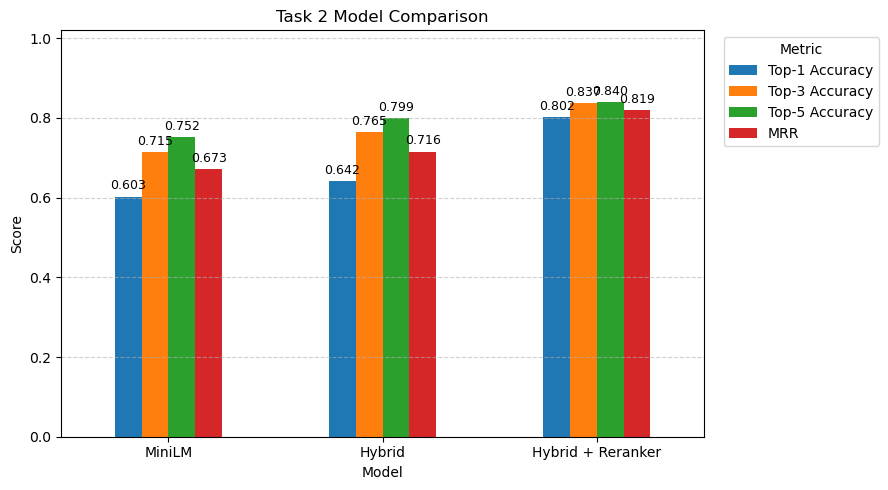

In [74]:
# [9.2] Plot final comparison chart with readable value labels

metrics = ["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy", "MRR"]

ax = comparison_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(9, 5)
)

# Add numeric labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.title("Task 2 Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.02)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

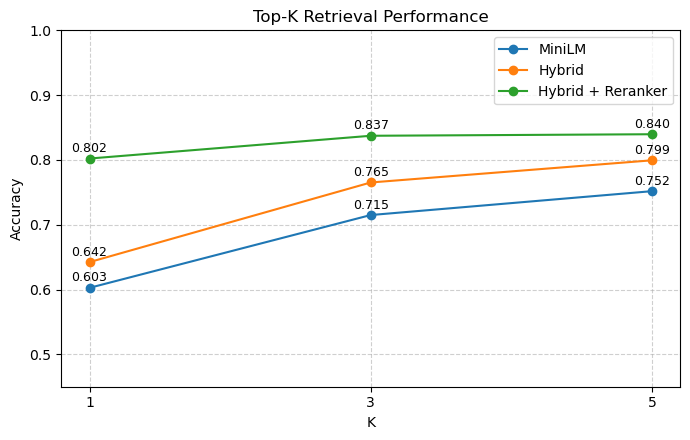

In [75]:
# [9.3] Plot Top-K retrieval curve

k_values = [1, 3, 5]

minilm_topk = [minilm_results[f"Top-{k} Accuracy"] for k in k_values]
hybrid_topk = [hybrid_results[f"Top-{k} Accuracy"] for k in k_values]
reranker_topk = [reranker_results[f"Top-{k} Accuracy"] for k in k_values]

plt.figure(figsize=(7, 4.5))

plt.plot(k_values, minilm_topk, marker="o", label="MiniLM")
plt.plot(k_values, hybrid_topk, marker="o", label="Hybrid")
plt.plot(k_values, reranker_topk, marker="o", label="Hybrid + Reranker")

# Add values near points
for x, y in zip(k_values, minilm_topk):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=9)

for x, y in zip(k_values, hybrid_topk):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=9)

for x, y in zip(k_values, reranker_topk):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center", fontsize=9)

plt.title("Top-K Retrieval Performance")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.ylim(0.45, 1.0)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Top-K Insight

All models improve as K increases, but the reranked model remains strongest at every evaluation depth.

In [76]:
# [9.4] Build absolute improvement table over the MiniLM baseline

improvement_df = pd.DataFrame({
    "Metric": ["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy", "MRR"],
    "Hybrid Gain": [
        hybrid_results["Top-1 Accuracy"] - minilm_results["Top-1 Accuracy"],
        hybrid_results["Top-3 Accuracy"] - minilm_results["Top-3 Accuracy"],
        hybrid_results["Top-5 Accuracy"] - minilm_results["Top-5 Accuracy"],
        hybrid_results["MRR"] - minilm_results["MRR"],
    ],
    "Hybrid + Reranker Gain": [
        reranker_results["Top-1 Accuracy"] - minilm_results["Top-1 Accuracy"],
        reranker_results["Top-3 Accuracy"] - minilm_results["Top-3 Accuracy"],
        reranker_results["Top-5 Accuracy"] - minilm_results["Top-5 Accuracy"],
        reranker_results["MRR"] - minilm_results["MRR"],
    ],
})

improvement_df

,Metric,Hybrid Gain,Hybrid + Reranker Gain
0,Top-1 Accuracy,0.039726,0.199553
1,Top-3 Accuracy,0.050250,0.122336
2,Top-5 Accuracy,0.047619,0.087872
3,MRR,0.043038,0.146929


### Gain Insight

The hybrid stage delivers the main performance jump, while reranking adds a further improvement on top of an already strong retrieval model.

### Final Insight

The Hybrid + Reranker model significantly improves idiom retrieval performance.

- Dense retrieval captures semantic similarity
- Hybrid retrieval adds lexical signals
- Cross-encoder reranking provides precise query–idiom interaction

The reranker contributes the largest performance gain, improving Top-1 accuracy by ~20% over the dense baseline.

Candidate Recall@10 (0.84) shows that further improvements may be possible by increasing the candidate pool.

### Error Analysis

To better understand model behavior, we analyze common failure cases in the context-to-idiom retrieval task.

Unlike classification, this task involves ranking semantically similar candidates, which introduces additional challenges.

In [80]:
# [9.5] Error analysis from final reranked predictions

prediction_rows = []

for i in range(len(test_df)):
    query = test_df.iloc[i]["example"]
    true_idiom = test_df.iloc[i]["idiom_canonical"]

    # Final reranked candidate indices from the cleaned pipeline
    ranked_indices = reranked_indices[i]

    pred_1 = idx_to_idiom[ranked_indices[0]]
    pred_2 = idx_to_idiom[ranked_indices[1]]
    pred_3 = idx_to_idiom[ranked_indices[2]]

    prediction_rows.append({
        "query": query,
        "true": true_idiom,
        "pred_1": pred_1,
        "pred_2": pred_2,
        "pred_3": pred_3,
        "is_correct": pred_1 == true_idiom
    })

prediction_df = pd.DataFrame(prediction_rows)

print("Prediction table built from final reranked results.")
print("Rows:", len(prediction_df))

prediction_df.head()

Prediction table built from final reranked results.
Rows: 7602


,query,true,pred_1,pred_2,pred_3,is_correct
0,Attendees received the inside scoop on upcoming regulatory changes during the briefing.,inside scoop,inside scoop,this just in,in other news,True
1,I think you overstepped the mark by criticizing her work so harshly.,overstep the mark,overstep the mark,I hardly know her,mark one's own homework,True
2,"The geopolitical situation in the region has become a pressure cooker, with tensions escalating rapidly.",pressure cooker,pressure cooker,pressure valve,boil up,True
3,Did you manage a flying visit to the museum during your trip?,flying visit,flying visit,on the fly,fly by,True
4,The children were in splits after watching the clown's silly antics at the party.,in splits,in splits,split one's sides,split screen,True


### Qualitative Evaluation (Demo)

To illustrate model behavior, we present several example queries and their top predictions after reranking.

In [84]:
# [9.6 - FINAL] Demo function using the full pipeline (Hybrid + Reranker)

def minmax_normalize(scores):
    """Normalize scores to the [0, 1] range safely."""
    scores = np.asarray(scores, dtype=float)
    score_min = scores.min()
    score_max = scores.max()

    if score_max - score_min < 1e-12:
        return np.zeros_like(scores, dtype=float)

    return (scores - score_min) / (score_max - score_min)


def demo_query(query_text, top_k=5, rerank_top_k=10):
    """Run full Hybrid + Reranker inference for a single query."""

    print(f"\nQuery: {query_text}\n")

    # Encode and normalize the query
    query_embedding = embedder.encode(
        [query_text],
        convert_to_numpy=True
    )[0]
    query_embedding = query_embedding / np.linalg.norm(query_embedding)

    # Dense similarity against the full idiom bank
    dense_scores = np.dot(query_embedding, idiom_embeddings.T)

    # BM25 lexical scores against the full idiom bank
    bm25_scores = np.asarray(
        bm25.get_scores(query_text.lower().split()),
        dtype=float
    )

    # Normalize both score types
    dense_scores_norm = minmax_normalize(dense_scores)
    bm25_scores_norm = minmax_normalize(bm25_scores)

    # Best hybrid weighting from your experiments
    hybrid_scores = 0.8 * dense_scores_norm + 0.2 * bm25_scores_norm

    # Keep only top candidates from the hybrid stage
    top_candidate_indices = np.argsort(-hybrid_scores)[:rerank_top_k]
    top_candidate_idioms = [idx_to_idiom[idx] for idx in top_candidate_indices]

    # Build query-candidate pairs for reranking
    rerank_pairs = [[query_text, idiom] for idiom in top_candidate_idioms]

    # Score with the reranker
    rerank_scores = reranker_model.predict(
        rerank_pairs,
        batch_size=32,
        show_progress_bar=False
    )

    # Sort candidates by reranker score
    reranked = sorted(
        zip(top_candidate_idioms, rerank_scores),
        key=lambda x: x[1],
        reverse=True
    )

    # Normalize reranker scores for display only
    scores_only = np.asarray([score for _, score in reranked], dtype=float)
    scores_norm = minmax_normalize(scores_only)

    # Print final predictions
    print("Top predictions:")
    for rank, ((idiom, _), score_n) in enumerate(zip(reranked, scores_norm), start=1):
        if rank > top_k:
            break
        print(f"{rank}. {idiom}  (score={score_n:.3f})")

In [85]:
# [11.2] Run demo examples

demo_query("He finally kicked the bucket after years of illness.")
demo_query("She revealed the secret and spilled the beans.")
demo_query("After failing again, he decided to throw in the towel.")


Query: He finally kicked the bucket after years of illness.

Top predictions:
1. kick the bucket  (score=1.000)
2. bucket down  (score=0.572)
3. bolt bucket  (score=0.563)
4. bucket brigade  (score=0.441)
5. bucket of bolts  (score=0.334)

Query: She revealed the secret and spilled the beans.

Top predictions:
1. spill the beans  (score=1.000)
2. spill one's guts  (score=0.345)
3. worst-kept secret  (score=0.325)
4. leak out  (score=0.237)
5. slip out  (score=0.231)

Query: After failing again, he decided to throw in the towel.

Top predictions:
1. throw in the towel  (score=1.000)
2. throw in at the deep end  (score=0.308)
3. throw good money after bad  (score=0.270)
4. throw overboard  (score=0.263)
5. throw up one's hands  (score=0.193)


### Demo Summary

In all three examples, the reranked pipeline retrieves the correct idiom at rank 1.

The remaining candidates are often semantically or lexically related, showing that the task is challenging even when the final prediction is correct.

### Task 2 Conclusion

The final Task 2 benchmark shows a clear progression from dense retrieval to hybrid retrieval and then to reranking.

The strongest results are achieved by the Hybrid + Reranker pipeline, which provides the most accurate and stable context-to-idiom retrieval performance in this notebook.

### Saving Inference Artifacts

We save the idiom bank, embeddings, and index mappings so the final retrieval pipeline can be reused in a separate inference notebook.

In [86]:
# [12.1 - FINAL] Save inference artifacts for Task 2 demo / Hugging Face

import pickle
from pathlib import Path
import numpy as np

# Directory for all reusable inference artifacts
ARTIFACT_DIR = Path("../artifacts/task2")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1) Save semantic idiom bank
# -----------------------------
task2_bank_df.to_csv(
    ARTIFACT_DIR / "idiom_bank.csv",
    index=False,
    encoding="utf-8-sig"
)

# -----------------------------
# 2) Save dense idiom embeddings
# -----------------------------
np.save(ARTIFACT_DIR / "idiom_embeddings.npy", idiom_embeddings)

# -----------------------------
# 3) Save index mappings
# -----------------------------
with open(ARTIFACT_DIR / "idiom_to_idx.pkl", "wb") as f:
    pickle.dump(idiom_to_idx, f)

with open(ARTIFACT_DIR / "idx_to_idiom.pkl", "wb") as f:
    pickle.dump(idx_to_idiom, f)

# -----------------------------
# 4) Save BM25 tokenized bank
# -----------------------------
with open(ARTIFACT_DIR / "bm25_tokens.pkl", "wb") as f:
    pickle.dump(idiom_tokens, f)

# -----------------------------
# 5) Save model names/config used
# -----------------------------
model_config = {
    "dense_model_name": "sentence-transformers/all-MiniLM-L6-v2",
    "reranker_model_name": "cross-encoder/ms-marco-MiniLM-L-6-v2",
    "hybrid_dense_weight": 0.8,
    "hybrid_bm25_weight": 0.2,
    "rerank_top_k": 10
}

with open(ARTIFACT_DIR / "model_config.pkl", "wb") as f:
    pickle.dump(model_config, f)

print("Artifacts saved to:", ARTIFACT_DIR.resolve())
print("\nSaved files:")
for path in sorted(ARTIFACT_DIR.iterdir()):
    print("-", path.name)

Artifacts saved to: C:\Users\ayman\Documents\IdiomX\artifacts\task2

Saved files:
- bm25.pkl
- bm25_tokens.pkl
- idiom_bank.csv
- idiom_embeddings.npy
- idiom_to_idx.pkl
- idx_to_idiom.pkl
- model_config.pkl


### Saving Inference Artifacts

We save the final idiom bank, embeddings, lexical index inputs, and mapping files
required to reproduce the full Hybrid + Reranker inference pipeline in a separate
notebook or Hugging Face demo.